# 04 Overlay

Intersects the reclamation polygons from stage 3 with the habitat map that was current before them, and writes the pieces to `data/processed/reclamation_habitat.gpkg` and a year x habitat table to `outputs/tables/04_year_habitat.csv`. All logic lives in `src/reclaim/overlay.py`.

- 2016-2018 detections use the 2010/11 map, 2019-2025 detections the 2018 map (`habitat.baseline_for_year`).
- Invalid geometries are repaired with `make_valid` (322 in 2010/11, 1,548 in 2018).
- The 2018 map has about 30 ha of overlapping polygons, under 1 ha of it inside reclamation. Where two polygons overlap, the one with the lower `OBJECTID` keeps the area, so nothing is counted twice.
- Parts that no map covers are labelled `Unmapped / open water`.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from reclaim import config, detect, overlay
cfg = config.load()
code_f, type_f = cfg['habitat']['code_field'], cfg['habitat']['type_field']

## 1. Run

In [2]:
pieces, table = overlay.run(cfg)

map_2010_11: 131 polygons (2016-2018) -> 367 mapped, 74 unmapped pieces


map_2018: 232 polygons (2019-2025) -> 1157 mapped, 181 unmapped pieces
wrote data/processed/reclamation_habitat.gpkg (1779 pieces) and outputs/tables/04_year_habitat.csv


## 2. Check: habitat areas add up to the reclaimed area

Per year, the pieces must sum to the reclamation area from stage 3 within 0.1%.

In [3]:
rec = gpd.read_file(detect.OUT)
check = pd.DataFrame({'reclaimed_ha': rec.assign(a=rec.area / 1e4).groupby('year').a.sum(),
                      'habitat_sum_ha': pieces.groupby('year').area_ha.sum()})
check['diff_pct'] = (check.habitat_sum_ha / check.reclaimed_ha - 1) * 100
assert check.diff_pct.abs().max() < 0.1
check.round(4)

,reclaimed_ha,habitat_sum_ha,diff_pct
year,,,
2016,156.78,156.7800,0.0000
2017,349.65,349.6500,0.0000
2018,324.78,324.7800,-0.0000
2019,268.90,268.9004,0.0001
2020,238.73,238.7300,0.0000
2021,192.51,192.5111,0.0006
2022,330.16,330.1893,0.0089
2023,210.51,210.5110,0.0005
2024,142.04,142.0403,0.0002


## 3. Year x habitat

Hectares per habitat and year. The two blocks use different maps with different class sets, so the rows are not directly comparable across 2018/2019.

In [4]:
wide = table.pivot_table(index=['baseline', type_f], columns='year', values='area_ha', aggfunc='sum', fill_value=0)
wide['total'] = wide.sum(axis=1)
wide.sort_values(['baseline', 'total'], ascending=[True, False]).round(1)

year                                               2016   2017   2018   2019  \
baseline    HABITAT_TYPE                                                       
map_2010_11 Unmapped / open water                 112.6  145.0  215.0    0.0   
            Water                                  35.2  157.0   85.4    0.0   
            Openland                                4.8   28.9   17.1    0.0   
            Other Vegetation                        0.8    7.7    3.6    0.0   
            Mudflat                                 1.0    5.4    0.3    0.0   
            Mangrove                                0.6    4.9    0.0    0.0   
            Shallow Water                           0.5    0.0    1.5    0.0   
            Sandflat                                0.2    0.1    1.1    0.0   
            Built-up                                0.8    0.0    0.4    0.0   
            Seagrass and Algae                      0.1    0.5    0.2    0.0   
            Rock Bund                               0.1    0.0    0.1    0.0   
            Sandy Beach                             0.0    0.1    0.0    0.0   
map_2018    Unmapped / open water                   0.0    0.0    0.0  208.8   
            Openland                                0.0    0.0    0.0   48.6   
            Water                                   0.0    0.0    0.0    1.8   
            Sand and Rubble                         0.0    0.0    0.0    3.6   
            Mudflat                                 0.0    0.0    0.0    0.1   
            Other Vegetation                        0.0    0.0    0.0    0.3   
            Sandflat                                0.0    0.0    0.0    1.2   
            Shallow Water                           0.0    0.0    0.0    0.6   
            Mangrove                                0.0    0.0    0.0    0.0   
            Seagrass Meadow                         0.0    0.0    0.0    0.0   
            Seagrass and Algae                      0.0    0.0    0.0    2.0   
            Sandy Beach                             0.0    0.0    0.0    0.3   
            Built-up                                0.0    0.0    0.0    1.5   
            Coastal Vegetation                      0.0    0.0    0.0    0.0   
            Coral Rubble with Seagrass and Algae    0.0    0.0    0.0    0.0   
            Rock Bund                               0.0    0.0    0.0    0.0   
            Coral on Rock Bund                      0.0    0.0    0.0    0.2   
            Rocky Shore                             0.0    0.0    0.0    0.0   

year                                               2020   2021   2022   2023  \
baseline    HABITAT_TYPE                                                       
map_2010_11 Unmapped / open water                   0.0    0.0    0.0    0.0   
            Water                                   0.0    0.0    0.0    0.0   
            Openland                                0.0    0.0    0.0    0.0   
            Other Vegetation                        0.0    0.0    0.0    0.0   
            Mudflat                                 0.0    0.0    0.0    0.0   
            Mangrove                                0.0    0.0    0.0    0.0   
            Shallow Water                           0.0    0.0    0.0    0.0   
            Sandflat                                0.0    0.0    0.0    0.0   
            Built-up                                0.0    0.0    0.0    0.0   
            Seagrass and Algae                      0.0    0.0    0.0    0.0   
            Rock Bund                               0.0    0.0    0.0    0.0   
            Sandy Beach                             0.0    0.0    0.0    0.0   
map_2018    Unmapped / open water                 160.0  115.3  257.9  156.4   
            Openland                               58.8   47.2   29.4   27.9   
            Water                                   4.9   11.9   22.4   16.7   
            Sand and Rubble                         8.3    3.3    2.3    0.3   

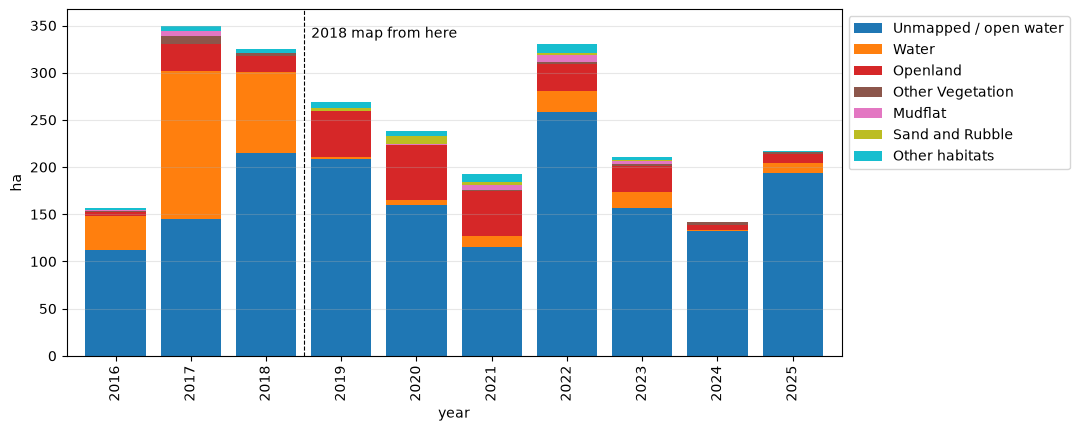

In [5]:
by_type = table.groupby(type_f).area_ha.sum().sort_values(ascending=False)
top = by_type.index[:6]
t = table.assign(cls=table[type_f].where(table[type_f].isin(top), 'Other habitats'))
stack = t.pivot_table(index='year', columns='cls', values='area_ha', aggfunc='sum', fill_value=0)[list(top) + ['Other habitats']]
ax = stack.plot.bar(stacked=True, figsize=(10, 4.5), colormap='tab10', width=0.8)
ax.axvline(2.5, color='k', ls='--', lw=0.8); ax.text(2.6, ax.get_ylim()[1] * 0.95, '2018 map from here', va='top')
ax.set_ylabel('ha'); ax.legend(bbox_to_anchor=(1, 1)); ax.grid(alpha=0.3, axis='y')

## 4. What the habitat maps cover

Most reclaimed area lies outside both habitat maps. The maps chart the nearshore zone; large projects such as the Tuas port and Pulau Tekong extend into open water beyond it. The map below shows the 2018 map's footprint against the 2019-2025 pieces.

unmapped share of all reclaimed area: 69.8%


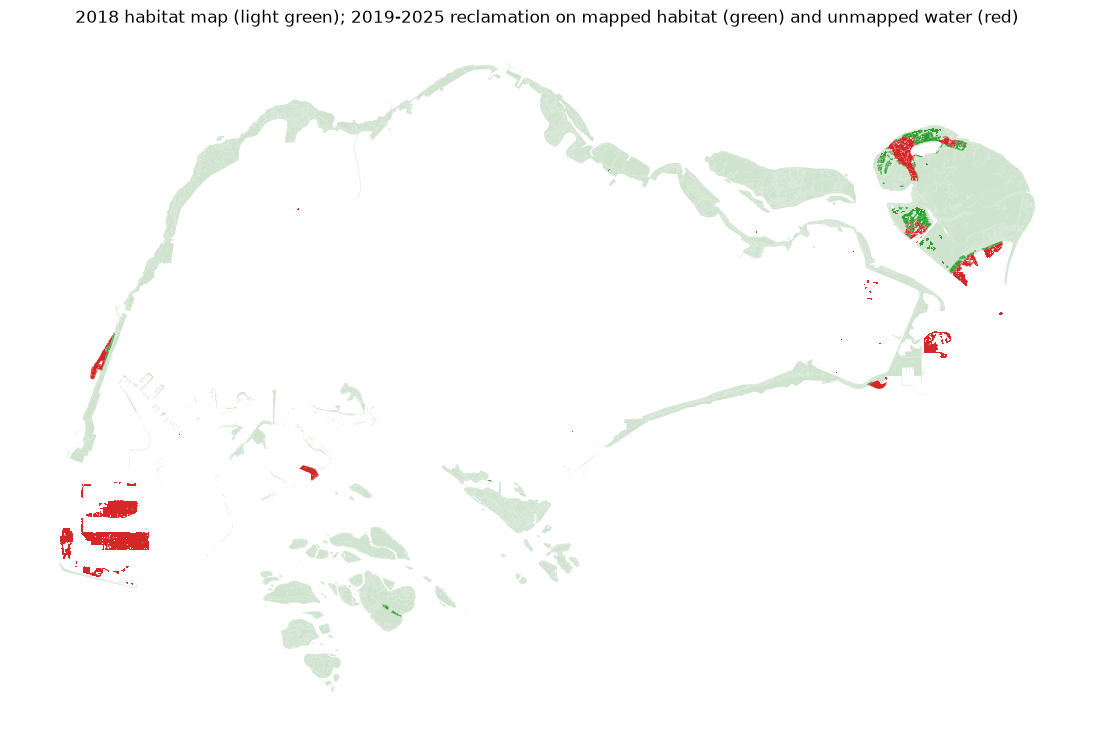

In [6]:
hab18 = overlay.habitat_map(cfg, 'map_2018')
p18 = pieces[pieces.baseline == 'map_2018']
fig, ax = plt.subplots(figsize=(15, 9))
hab18.plot(ax=ax, color='#cfe3cf', lw=0)
p18[p18[type_f] != cfg['habitat']['unmapped_label']].plot(ax=ax, color='tab:green')
p18[p18[type_f] == cfg['habitat']['unmapped_label']].plot(ax=ax, color='tab:red')
ax.set_title('2018 habitat map (light green); 2019-2025 reclamation on mapped habitat (green) and unmapped water (red)')
ax.set_axis_off()
share = table.groupby(table[type_f] == cfg['habitat']['unmapped_label']).area_ha.sum()
print(f"unmapped share of all reclaimed area: {share[True] / share.sum() * 100:.1f}%")

## 5. Notes for stage 5

- **Unmapped dominates.** RQ2 can only describe the mapped minority of reclaimed area. RQ3 has to state its denominator with that in mind.
- **Pulau Tekong in the 2018 map.** Almost all of the 2018 map's `Openland` under 2019-2025 reclamation lies at Pulau Tekong. The map already shows the reclamation works there as open land, while the masks still saw water ponds inside them until 2019-2023. This is reclamation replacing reclamation in progress, not natural open land.
- **Pulau Tekong in the 2010/11 map.** The 2010/11 map's `Water` class under 2016-2018 reclamation is also almost all at Pulau Tekong.
- **Inland ponds.** The inland ponds kept in stage 3 (about 62 ha, mostly 2016) fall mainly into `Unmapped / open water`.

In [7]:
from pyproj import Transformer
to = Transformer.from_crs(cfg['project']['crs'], 'EPSG:4326', always_xy=True)
c = pieces.representative_point()
lon, lat = to.transform(c.x.values, c.y.values)
tekong = (lon > 103.97) & (lat > 1.37)
s = pieces.assign(at_tekong=tekong).groupby(['baseline', type_f, 'at_tekong']).area_ha.sum().unstack(fill_value=0).round(1)
s.loc[[('map_2018', 'Openland'), ('map_2010_11', 'Water')]]

,at_tekong,False,True
baseline,HABITAT_TYPE,,
map_2018,Openland,0.6,225.1
map_2010_11,Water,4.9,272.7
